In [17]:
import os
import cv2
import json
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization
)

from tensorflow.keras.models import Model

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

warnings.filterwarnings("ignore")

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.21.0


In [18]:
dataset_path = r"C:\Users\Dell\Downloads\archive\lung_colon_image_set"

colon_path = os.path.join(dataset_path, "colon_image_sets")
lung_path = os.path.join(dataset_path, "lung_image_sets")

In [19]:
classes = {}

for folder in os.listdir(colon_path):
    classes[folder] = len(
        os.listdir(
            os.path.join(colon_path, folder)
        )
    )

for folder in os.listdir(lung_path):
    classes[folder] = len(
        os.listdir(
            os.path.join(lung_path, folder)
        )
    )

df = pd.DataFrame(
    list(classes.items()),
    columns=["Class", "Images"]
)

df

,Class,Images
0,colon_aca,4999
1,colon_n,4999
2,lung_aca,4999
3,lung_n,4999
4,lung_scc,4999


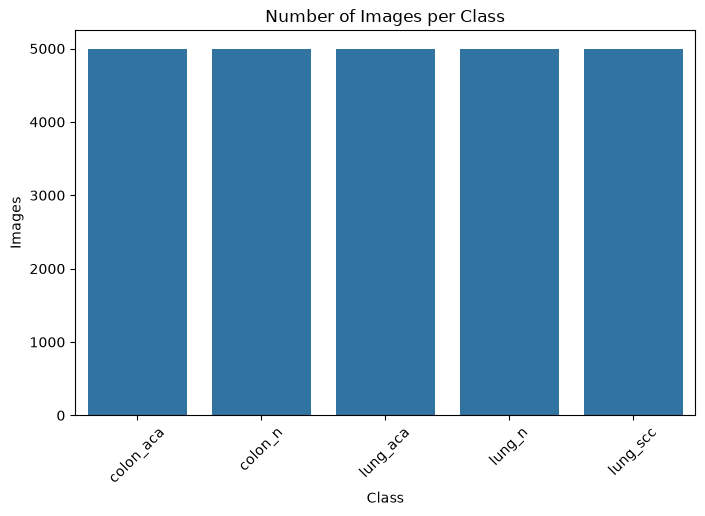

In [20]:
plt.figure(figsize=(8,5))


sns.barplot(
    data=df,
    x="Class",
    y="Images"
)


plt.title(
    "Number of Images per Class"
)


plt.xticks(rotation=45)


plt.show()

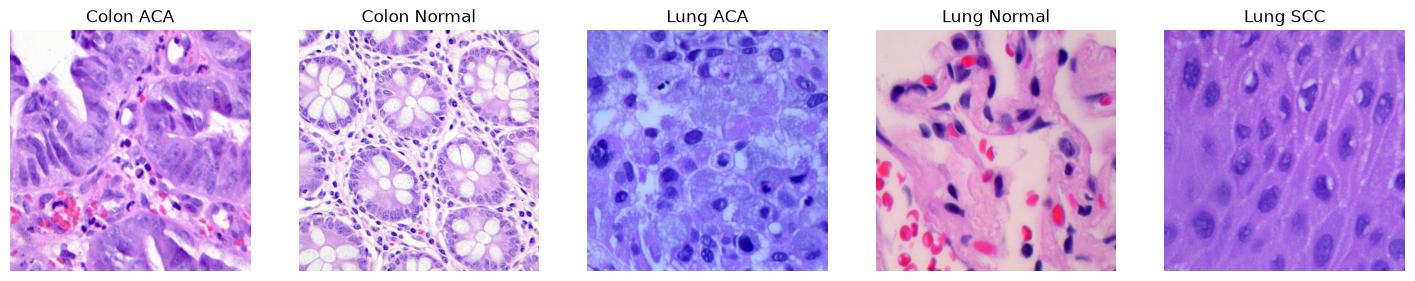

In [21]:
fig, axes = plt.subplots(1,5,figsize=(18,5))

sample_classes = [
    os.path.join(colon_path,"colon_aca"),
    os.path.join(colon_path,"colon_n"),
    os.path.join(lung_path,"lung_aca"),
    os.path.join(lung_path,"lung_n"),
    os.path.join(lung_path,"lung_scc")
]

titles = [
    "Colon ACA",
    "Colon Normal",
    "Lung ACA",
    "Lung Normal",
    "Lung SCC"
]

for i, folder in enumerate(sample_classes):

    img_name = random.choice(os.listdir(folder))

    img_path = os.path.join(folder,img_name)

    img = cv2.imread(img_path)

    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    axes[i].imshow(img)

    axes[i].set_title(titles[i])

    axes[i].axis("off")

plt.show()

In [22]:
paths = []
labels = []

# Colon Images
for folder in os.listdir(colon_path):

    folder_path = os.path.join(colon_path, folder)

    for img in os.listdir(folder_path):

        paths.append(
            os.path.join(folder_path, img)
        )

        labels.append(folder)


# Lung Images
for folder in os.listdir(lung_path):

    folder_path = os.path.join(lung_path, folder)

    for img in os.listdir(folder_path):

        paths.append(
            os.path.join(folder_path, img)
        )

        labels.append(folder)


data = pd.DataFrame({

    "Path": paths,
    "Label": labels

})

data.head()

,Path,Label
0,C:\Users\Dell\Downloads\archive\lung_colon_ima...,colon_aca
1,C:\Users\Dell\Downloads\archive\lung_colon_ima...,colon_aca
2,C:\Users\Dell\Downloads\archive\lung_colon_ima...,colon_aca
3,C:\Users\Dell\Downloads\archive\lung_colon_ima...,colon_aca
4,C:\Users\Dell\Downloads\archive\lung_colon_ima...,colon_aca


In [23]:
print("Dataset Shape :", data.shape)

print()

print(data["Label"].value_counts())

Dataset Shape : (24995, 2)

Label
colon_aca    4999
colon_n      4999
lung_aca     4999
lung_n       4999
lung_scc     4999
Name: count, dtype: int64


In [24]:
train_df, test_df = train_test_split(

    data,

    test_size=0.20,

    random_state=42,

    stratify=data["Label"]

)

train_df, valid_df = train_test_split(

    train_df,

    test_size=0.20,

    random_state=42,

    stratify=train_df["Label"]

)

print("Training :", len(train_df))
print("Validation :", len(valid_df))
print("Testing :", len(test_df))

Training : 15996
Validation : 4000
Testing : 4999


In [25]:
IMAGE_SIZE = (224,224)

BATCH_SIZE = 32


train_generator = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    rotation_range=25,

    zoom_range=0.30,

    width_shift_range=0.15,

    height_shift_range=0.15,

    shear_range=0.20,

    brightness_range=[0.7,1.3],

    horizontal_flip=True,

    fill_mode="nearest"

)


valid_generator = ImageDataGenerator(

    preprocessing_function=preprocess_input

)


test_generator = ImageDataGenerator(

    preprocessing_function=preprocess_input

)

In [26]:
train_data = train_generator.flow_from_dataframe(

    dataframe=train_df,

    x_col="Path",

    y_col="Label",

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=True

)


valid_data = valid_generator.flow_from_dataframe(

    dataframe=valid_df,

    x_col="Path",

    y_col="Label",

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=False

)


test_data = test_generator.flow_from_dataframe(

    dataframe=test_df,

    x_col="Path",

    y_col="Label",

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=False

)

Found 15996 validated image filenames belonging to 5 classes.
Found 4000 validated image filenames belonging to 5 classes.
Found 4999 validated image filenames belonging to 5 classes.


In [27]:
base_model = EfficientNetB0(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)

)

# Fine-Tuning
base_model.trainable = True


for layer in base_model.layers[:-30]:
    layer.trainable = False


x = base_model.output

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(
    512,
    activation="relu"
)(x)

x = Dropout(0.5)(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.3)(x)

output = Dense(
    5,
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,843,176 (18.48 MB)

 Trainable params: 2,287,205 (8.72 MB)

 Non-trainable params: 2,555,971 (9.75 MB)

In [28]:
model.compile(

    optimizer=Adam(
        learning_rate=1e-5
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy"
    ]

)

print("Model Compiled Successfully")

Model Compiled Successfully


In [29]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True,

    verbose=1

)


reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=2,

    verbose=1

)


checkpoint = ModelCheckpoint(

    "best_efficientnet_model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

In [30]:
history = model.fit(

    train_data,

    validation_data=valid_data,

    epochs=10,

    callbacks=[

        early_stop,

        reduce_lr,

        checkpoint

    ]

)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4892 - loss: 1.3976
Epoch 1: val_accuracy improved from None to 0.87825, saving model to best_efficientnet_model.keras

Epoch 1: finished saving model to best_efficientnet_model.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 857s 2s/step - accuracy: 0.4892 - loss: 1.3976 - val_accuracy: 0.8783 - val_loss: 0.4248 - learning_rate: 1.0000e-05
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7479 - loss: 0.6740
Epoch 2: val_accuracy improved from 0.87825 to 0.92225, saving model to best_efficientnet_model.keras

Epoch 2: finished saving model to best_efficientnet_model.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 580s 1s/step - accuracy: 0.7479 - loss: 0.6740 - val_accuracy: 0.9222 - val_loss: 0.2381 - learning_rate: 1.0000e-05
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8300 - loss: 0.4586
Epoch 3: val_accuracy improved from 0.92225 to 0.93825, saving model to best_efficientnet_model.keras

Epoch 3: finished s

In [31]:
import tensorflow as tf
import json

model = tf.keras.models.load_model("lung_colon_efficientnet_final.keras")

with open("classes.json", "r") as f:
    class_names = json.load(f)

print("Model Loaded Successfully")

Model Loaded Successfully


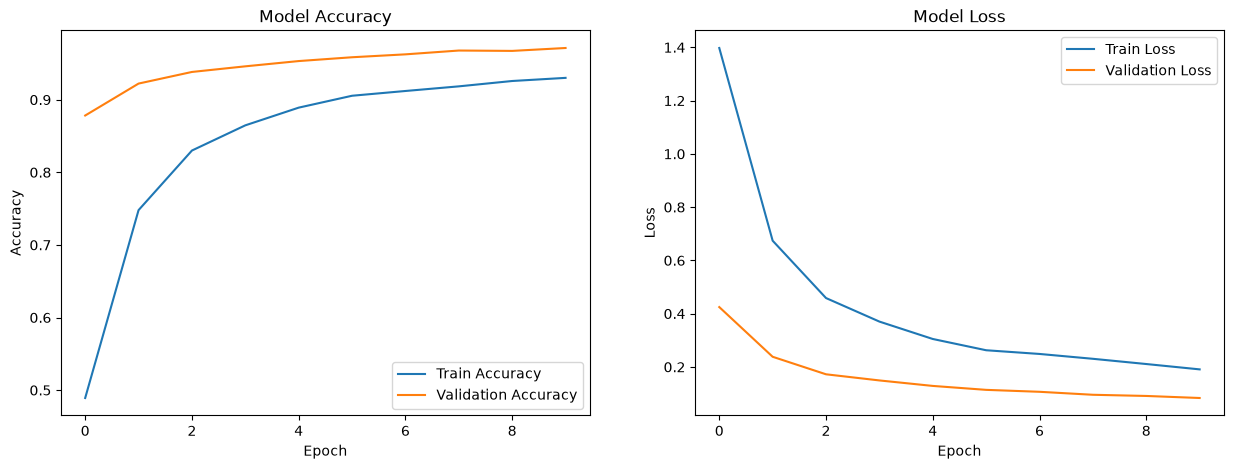

In [32]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()


plt.subplot(1,2,2)

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [33]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

loss, accuracy = model.evaluate(
    test_data,
    verbose=1
)

predictions = model.predict(
    test_data,
    verbose=1
)

y_pred = np.argmax(
    predictions,
    axis=1
)

y_true = test_data.classes


precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("="*50)

print(f"Test Loss      : {loss:.4f}")
print(f"Test Accuracy  : {accuracy*100:.2f}%")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1-Score       : {f1:.4f}")

print("="*50)

157/157 ━━━━━━━━━━━━━━━━━━━━ 91s 561ms/step - accuracy: 0.9780 - loss: 0.0677
157/157 ━━━━━━━━━━━━━━━━━━━━ 105s 656ms/step
Test Loss      : 0.0677
Test Accuracy  : 97.80%
Precision      : 0.9779
Recall         : 0.9780
F1-Score       : 0.9779


In [34]:
class_names = list(
    test_data.class_indices.keys()
)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

   colon_aca       0.99      0.99      0.99      1000
     colon_n       0.99      1.00      1.00       999
    lung_aca       0.95      0.95      0.95      1000
      lung_n       0.99      1.00      0.99      1000
    lung_scc       0.97      0.95      0.96      1000

    accuracy                           0.98      4999
   macro avg       0.98      0.98      0.98      4999
weighted avg       0.98      0.98      0.98      4999



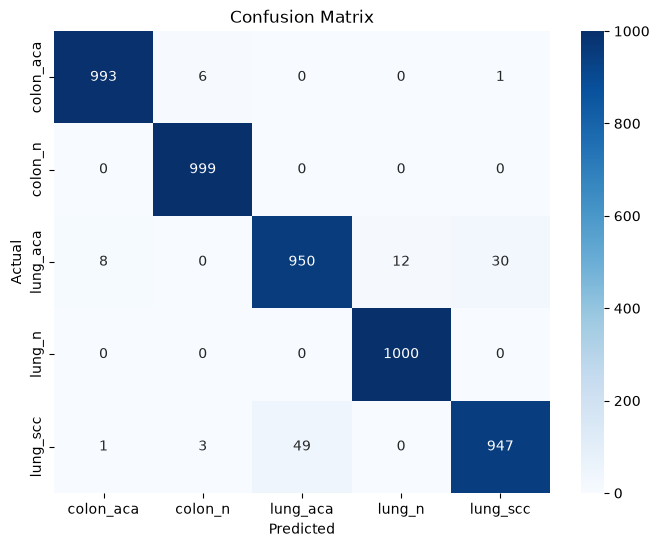

In [65]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

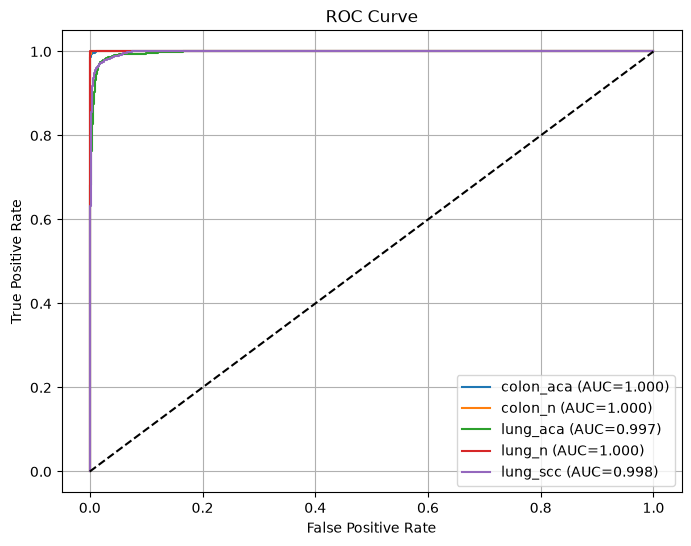

In [35]:
y_true_bin = label_binarize(
    y_true,
    classes=range(len(class_names))
)

plt.figure(figsize=(8,6))

for i in range(len(class_names)):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:,i],
        predictions[:,i]
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC={roc_auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    "k--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.show()

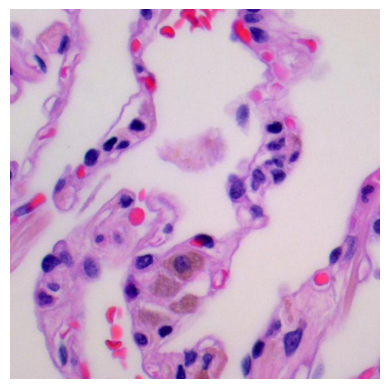

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Prediction : lung_n
Confidence : 100.00%


In [36]:
image_path = r"C:\Users\Dell\Desktop\cn.jpeg"
image = cv2.imread(image_path)

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

plt.imshow(image)
plt.axis("off")
plt.show()


img = cv2.resize(
    image,
    (224,224)
)

img = preprocess_input(
    img.astype(np.float32)
)

img = np.expand_dims(
    img,
    axis=0
)

prediction = model.predict(img)

predicted_class = class_names[
    np.argmax(prediction)
]

confidence = np.max(prediction)

print("Prediction :", predicted_class)

print(f"Confidence : {confidence*100:.2f}%")

if confidence < 0.80:
    print("Warning: Low confidence prediction. The image may differ from the training data.")